# Benchmark de modelos - CPRE 4 classes

Notebook para testar vários modelos pré-treinados no mesmo split por paciente e comparar por **macro F1**.

Começa com poucas épocas para escolher candidatos. Depois aumenta as épocas no melhor modelo.

In [1]:
# =========================
# 1. Imports e configuração
# =========================

from pathlib import Path
import os, gc, random, warnings, json, time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ===== CONFIGURAÇÃO PRINCIPAL =====
DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'benchmark_models_4class'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
EPOCHS = 8          # benchmark rápido; depois aumenta para 20/30 no melhor modelo
PATIENCE = 3
LR_BACKBONE = 1e-5
LR_HEAD = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
BASELINE_MACRO_F1 = 0.738

FREEZE_BACKBONE_FIRST = True
USE_CLASS_WEIGHTS = True
USE_AMP = True
SEED = 42

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/benchmark_models_4class
Models: /mounts/mecd-ap-g5/models/benchmark_models_4class


In [2]:
# =========================
# 2. Reprodutibilidade e GPU
# =========================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def clean_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

clean_cuda()

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [4]:
# =========================
# 3. Carregamento e preparação dos metadados
# =========================

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

df = pd.read_csv(METADATA_PATH)
print("Shape original:", df.shape)
display(df.head())
print("Colunas:", df.columns.tolist())

# =========================
# Detetar colunas principais
# =========================

possible_label_cols = [
    "Label", "label", "class", "Class", "diagnosis", "Diagnosis",
    "category", "Category", "target", "Target", "finding", "Finding"
]

possible_image_cols = [
    "processed_image_path", "raw_image_path",
    "image_path", "filepath", "file_path", "path",
    "filename", "file", "image", "Image"
]

possible_patient_cols = [
    "patient_id", "PatientID", "patient", "Patient",
    "case_id", "case", "study_id"
]

label_col = next((c for c in possible_label_cols if c in df.columns), None)
image_col = next((c for c in possible_image_cols if c in df.columns), None)
patient_col = next((c for c in possible_patient_cols if c in df.columns), None)

assert label_col is not None, f"Não encontrei coluna de label. Colunas: {df.columns.tolist()}"
assert image_col is not None, f"Não encontrei coluna de caminho de imagem. Colunas: {df.columns.tolist()}"

if patient_col is None:
    print("Aviso: não encontrei patient_id. Vou usar o índice como grupo.")
    df["patient_id"] = df.index.astype(str)
    patient_col = "patient_id"

print("Coluna de label usada:", label_col)
print("Coluna de imagem usada:", image_col)
print("Coluna de paciente usada:", patient_col)

assert label_col is not None, f"Não encontrei coluna de label. Colunas: {df.columns.tolist()}"
assert image_col is not None, f"Não encontrei coluna de caminho de imagem. Colunas: {df.columns.tolist()}"

if patient_col is None:
    df["patient_id"] = df.index.astype(str)
    patient_col = "patient_id"
    print("Aviso: não encontrei coluna de paciente; foi criado patient_id artificial.")

print("Coluna de label:", label_col)
print("Coluna de imagem:", image_col)
print("Coluna de grupo:", patient_col)

# Aplicar filtro Keep, se existir
for keep_col in ["status", "Status", "keep", "Keep", "selection", "Selection"]:
    if keep_col in df.columns:
        vals = df[keep_col].astype(str).str.lower()
        if vals.isin(["keep"]).any():
            df = df[vals.eq("keep")].copy()
            print(f"Filtro Keep aplicado pela coluna {keep_col}. Shape:", df.shape)
        break

# Remover não etiquetadas
df = df[~df[label_col].astype(str).str.lower().isin(["unlabelled", "unlabeled", "nan", "none", ""])].copy()

def map_to_4_classes(label):
    label = str(label).strip()
    label_low = label.lower().replace("_", " ")
    if label_low in ["benign stricture", "malignant stricture", "stricture", "strictures"]:
        return "Stricture"
    if label_low in ["biliary leaks", "biliary leak", "bile leaks", "bile leak"]:
        return "Biliary Leaks"
    if label_low in ["lithiasis", "stones", "stone", "biliary lithiasis"]:
        return "Lithiasis"
    if label_low == "normal":
        return "Normal"
    return label

df["label"] = df[label_col].apply(map_to_4_classes)

class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df = df[df["label"].isin(class_names)].copy()
df["target"] = df["label"].map(class_to_idx).astype(int)
df["patient_id"] = df[patient_col].astype(str)

def resolve_image_path(x):
    p = Path(str(x))
    if p.exists():
        return str(p)
    p2 = DATASET_DIR / p
    if p2.exists():
        return str(p2)
    p3 = PROCESSED_IMAGES_DIR / p.name
    if p3.exists():
        return str(p3)
    return None

df["image_path"] = df[image_col].apply(resolve_image_path)

print("Distribuição 4 classes:")
display(df["label"].value_counts())
print("Imagens existentes:", df["image_path"].notna().sum(), "/", len(df))

df = df[df["image_path"].notna()].copy()
assert len(df) > 0, "Depois do filtro, o dataframe ficou vazio."
assert df["image_path"].notna().all(), "Há imagens sem caminho válido."

print("Shape final:", df.shape)
display(df[["image_path", "label", "target", "patient_id"]].head())

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Coluna de label usada: Label
Coluna de imagem usada: processed_image_path
Coluna de paciente usada: patient_id
Coluna de label: Label
Coluna de imagem: processed_image_path
Coluna de grupo: patient_id
Filtro Keep aplicado pela coluna Keep. Shape: (15216, 12)
Distribuição 4 classes:


label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

Imagens existentes: 1568 / 1568
Shape final: (1568, 15)


,image_path,label,target,patient_id
23,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3,3
36,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2,5
50,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3,6
65,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2,9
68,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2,9


In [5]:
# =========================
# 4. Split por paciente
# =========================

groups = df["patient_id"].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df, df["target"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, temp_df["target"], groups=temp_df["patient_id"].values))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train:", train_df.shape)
display(train_df["label"].value_counts())
print("Val:", val_df.shape)
display(val_df["label"].value_counts())
print("Test:", test_df.shape)
display(test_df["label"].value_counts())

train_df.to_csv(RESULTS_DIR / "train_split.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split.csv", index=False)

Train: (1064, 15)


label
Lithiasis        507
Stricture        276
Normal           190
Biliary Leaks     91
Name: count, dtype: int64

Val: (226, 15)


label
Lithiasis        106
Stricture         65
Normal            38
Biliary Leaks     17
Name: count, dtype: int64

Test: (278, 15)


label
Lithiasis        113
Normal            71
Stricture         51
Biliary Leaks     43
Name: count, dtype: int64

In [6]:
# =========================
# 5. Dataset e DataLoaders
# =========================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["target"])
        return img, label

train_dataset = ERCPDataset(train_df, train_transform)
val_dataset = ERCPDataset(val_df, eval_transform)
test_dataset = ERCPDataset(test_df, eval_transform)

class_counts = train_df["target"].value_counts().sort_index()
class_weights_np = len(train_df) / (len(class_names) * class_counts.values)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

print("Class counts:", class_counts.to_dict())
print("Class weights:", class_weights_np)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

Class counts: {0: 91, 1: 507, 2: 276, 3: 190}
Class weights: [2.92307692 0.52465483 0.96376812 1.4       ]


In [7]:
# =========================
# 6. Fábrica de modelos
# =========================

NUM_CLASSES = len(class_names)

def set_requires_grad(module, requires_grad):
    for p in module.parameters():
        p.requires_grad = requires_grad

def replace_classifier(model, num_classes):
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=0.35), nn.Linear(in_features, num_classes))
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, nn.Linear):
            in_features = model.classifier.in_features
            model.classifier = nn.Sequential(nn.Dropout(p=0.35), nn.Linear(in_features, num_classes))
        elif isinstance(model.classifier, nn.Sequential):
            for i in reversed(range(len(model.classifier))):
                if isinstance(model.classifier[i], nn.Linear):
                    in_features = model.classifier[i].in_features
                    model.classifier[i] = nn.Linear(in_features, num_classes)
                    break
    else:
        raise ValueError("Não consegui substituir o classificador.")
    return model

def get_backbone_and_head_params(model):
    if hasattr(model, "fc"):
        head_params = list(model.fc.parameters())
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    elif hasattr(model, "classifier"):
        head_params = list(model.classifier.parameters())
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier.")]
    else:
        head_params = []
        backbone_params = list(model.parameters())
    return backbone_params, head_params

def freeze_backbone(model):
    backbone_params, head_params = get_backbone_and_head_params(model)
    for p in backbone_params:
        p.requires_grad = False
    for p in head_params:
        p.requires_grad = True

def unfreeze_last_part(model):
    freeze_backbone(model)

    if hasattr(model, "features"):
        for block in list(model.features.children())[-2:]:
            set_requires_grad(block, True)

    if hasattr(model, "layer4"):
        set_requires_grad(model.layer4, True)

    if hasattr(model, "trunk_output"):
        try:
            set_requires_grad(model.trunk_output.block4, True)
        except Exception:
            set_requires_grad(model.trunk_output, True)

    _, head_params = get_backbone_and_head_params(model)
    for p in head_params:
        p.requires_grad = True

def build_model(model_name):
    name = model_name.lower()

    if name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    elif name == "efficientnet_b1":
        model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    elif name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif name == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    elif name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    elif name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    elif name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    elif name == "regnet_y_400mf":
        model = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.IMAGENET1K_V2)
    elif name == "regnet_y_800mf":
        model = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.IMAGENET1K_V2)
    elif name == "shufflenet_v2_x1_0":
        model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Modelo não suportado: {model_name}")

    return replace_classifier(model, NUM_CLASSES)

In [8]:
# =========================
# 7. Treino e avaliação
# =========================

def make_optimizer(model):
    backbone_params, head_params = get_backbone_and_head_params(model)
    return torch.optim.AdamW(
        [
            {"params": [p for p in backbone_params if p.requires_grad], "lr": LR_BACKBONE},
            {"params": [p for p in head_params if p.requires_grad], "lr": LR_HEAD},
        ],
        weight_decay=WEIGHT_DECAY
    )

def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, n = 0.0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=USE_AMP and torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels) if criterion is not None else None

            preds = torch.argmax(logits, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            if loss is not None:
                total_loss += loss.item() * images.size(0)
                n += images.size(0)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    return {
        "loss": total_loss / max(n, 1) if criterion is not None else np.nan,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
    }, all_labels, all_preds

def train_one_model(model_name, epochs=EPOCHS, patience=PATIENCE):
    print("\\n" + "=" * 80)
    print("A treinar:", model_name)
    print("=" * 80)

    clean_cuda()
    seed_everything(SEED)

    model = build_model(model_name)

    if FREEZE_BACKBONE_FIRST:
        freeze_backbone(model)
    else:
        unfreeze_last_part(model)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if USE_CLASS_WEIGHTS else None,
        label_smoothing=LABEL_SMOOTHING
    )

    optimizer = make_optimizer(model)
    scaler = GradScaler(enabled=USE_AMP and torch.cuda.is_available())

    best_val_f1 = -1
    best_path = MODELS_DIR / f"{model_name}_best.pt"
    history = []
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n = 0.0, 0

        if epoch == 3 and FREEZE_BACKBONE_FIRST:
            print("A desbloquear parcialmente o backbone para fine-tuning...")
            unfreeze_last_part(model)
            optimizer = make_optimizer(model)

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=USE_AMP and torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * images.size(0)
            n += images.size(0)

        train_loss = total_loss / max(n, 1)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)

        row = {"model": model_name, "epoch": epoch, "train_loss": train_loss}
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            torch.save({
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "img_size": IMG_SIZE,
                "best_val_macro_f1": best_val_f1,
            }, best_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    test_metrics, test_y, test_pred = evaluate(model, test_loader, criterion)

    print("\\nTeste macro F1:", test_metrics["macro_f1"])
    print("Diferença para baseline:", test_metrics["macro_f1"] - BASELINE_MACRO_F1)

    report = classification_report(
        test_y, test_pred, target_names=class_names,
        zero_division=0, output_dict=True
    )
    pd.DataFrame(report).transpose().to_csv(RESULTS_DIR / f"{model_name}_classification_report.csv")

    cm = confusion_matrix(test_y, test_pred, labels=list(range(NUM_CLASSES)))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        RESULTS_DIR / f"{model_name}_confusion_matrix.csv"
    )

    pd.DataFrame(history).to_csv(RESULTS_DIR / f"{model_name}_history.csv", index=False)

    summary = {
        "model": model_name,
        "best_val_macro_f1": best_val_f1,
        **{f"test_{k}": v for k, v in test_metrics.items()},
        "baseline_macro_f1": BASELINE_MACRO_F1,
        "delta_vs_baseline": test_metrics["macro_f1"] - BASELINE_MACRO_F1,
        "best_model_path": str(best_path)
    }

    del model, optimizer, scaler, criterion
    clean_cuda()

    return summary

In [9]:
# =========================
# 8. Modelos a testar
# =========================

MODELS_TO_TEST = [
    "efficientnet_b0",
    "resnet18",
    "resnet34",
    "densenet121",
    "mobilenet_v3_large",
    "regnet_y_400mf",
    "regnet_y_800mf",
    "shufflenet_v2_x1_0",
]

print("Modelos a testar:")
for m in MODELS_TO_TEST:
    print("-", m)

Modelos a testar:
- efficientnet_b0
- resnet18
- resnet34
- densenet121
- mobilenet_v3_large
- regnet_y_400mf
- regnet_y_800mf
- shufflenet_v2_x1_0


In [10]:
# =========================
# 9. Correr benchmark
# =========================

all_summaries = []

for model_name in MODELS_TO_TEST:
    try:
        summary = train_one_model(model_name)
        all_summaries.append(summary)

        summary_df = pd.DataFrame(all_summaries).sort_values(
            "test_macro_f1", ascending=False
        )
        summary_df.to_csv(RESULTS_DIR / "benchmark_summary_partial.csv", index=False)
        display(summary_df)

    except RuntimeError as e:
        print(f"ERRO no modelo {model_name}: {e}")
        clean_cuda()

summary_df = pd.DataFrame(all_summaries).sort_values(
    "test_macro_f1", ascending=False
)

summary_path = RESULTS_DIR / "benchmark_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Resumo guardado em:", summary_path)
display(summary_df)

\n================================================================================
A treinar: efficientnet_b0


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /mounts/mecd-ap-g5/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:01<00:00, 11.3MB/s]


ERRO no modelo efficientnet_b0: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 47.37 GiB of which 2.12 MiB is free. Process 39870 has 614.00 MiB memory in use. Process 66684 has 904.00 MiB memory in use. Process 69366 has 632.00 MiB memory in use. Process 86926 has 4.79 GiB memory in use. Process 91425 has 1.34 GiB memory in use. Including non-PyTorch memory, this process has 580.00 MiB memory in use. Of the allocated memory 38.63 MiB is allocated by PyTorch, and 17.37 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
\n================================================================================
A treinar: resnet18


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /mounts/mecd-ap-g5/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:04<00:00, 10.7MB/s]


ERRO no modelo resnet18: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 47.37 GiB of which 14.12 MiB is free. Process 39870 has 614.00 MiB memory in use. Process 66684 has 904.00 MiB memory in use. Process 69366 has 632.00 MiB memory in use. Process 86926 has 4.79 GiB memory in use. Process 91425 has 1.34 GiB memory in use. Including non-PyTorch memory, this process has 568.00 MiB memory in use. Of the allocated memory 31.40 MiB is allocated by PyTorch, and 12.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
\n================================================================================
A treinar: resnet34


...

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /mounts/mecd-ap-g5/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 10.4MB/s]


Epoch 01/8 | train_loss=1.4205 | val_loss=1.4287 | val_macro_f1=0.2725 | val_bal_acc=0.3210
Epoch 02/8 | train_loss=1.4182 | val_loss=1.4285 | val_macro_f1=0.2565 | val_bal_acc=0.3006
A desbloquear parcialmente o backbone para fine-tuning...
Epoch 03/8 | train_loss=1.4173 | val_loss=1.4258 | val_macro_f1=0.2346 | val_bal_acc=0.2876
Epoch 04/8 | train_loss=1.4145 | val_loss=1.4273 | val_macro_f1=0.2311 | val_bal_acc=0.2806
Early stopping.
\nTeste macro F1: 0.17252958106811642
Diferença para baseline: -0.5654704189318835


,model,best_val_macro_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,baseline_macro_f1,delta_vs_baseline,best_model_path
0,densenet121,0.273697,1.392067,0.424460,0.328394,0.326422,0.398386,0.738,-0.411578,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
1,mobilenet_v3_large,0.283053,1.468680,0.320144,0.284680,0.291912,0.338885,0.738,-0.446088,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
2,regnet_y_400mf,0.251936,1.464599,0.237410,0.259052,0.229092,0.240558,0.738,-0.508908,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
3,regnet_y_800mf,0.240736,1.447704,0.215827,0.196943,0.192928,0.225224,0.738,-0.545072,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
4,shufflenet_v2_x1_0,0.272544,1.422607,0.291367,0.235685,0.172530,0.227595,0.738,-0.565470,/mounts/mecd-ap-g5/models/benchmark_models_4cl...


Resumo guardado em: /mounts/mecd-ap-g5/results/benchmark_models_4class/benchmark_summary.csv


,model,best_val_macro_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,baseline_macro_f1,delta_vs_baseline,best_model_path
0,densenet121,0.273697,1.392067,0.424460,0.328394,0.326422,0.398386,0.738,-0.411578,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
1,mobilenet_v3_large,0.283053,1.468680,0.320144,0.284680,0.291912,0.338885,0.738,-0.446088,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
2,regnet_y_400mf,0.251936,1.464599,0.237410,0.259052,0.229092,0.240558,0.738,-0.508908,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
3,regnet_y_800mf,0.240736,1.447704,0.215827,0.196943,0.192928,0.225224,0.738,-0.545072,/mounts/mecd-ap-g5/models/benchmark_models_4cl...
4,shufflenet_v2_x1_0,0.272544,1.422607,0.291367,0.235685,0.172530,0.227595,0.738,-0.565470,/mounts/mecd-ap-g5/models/benchmark_models_4cl...


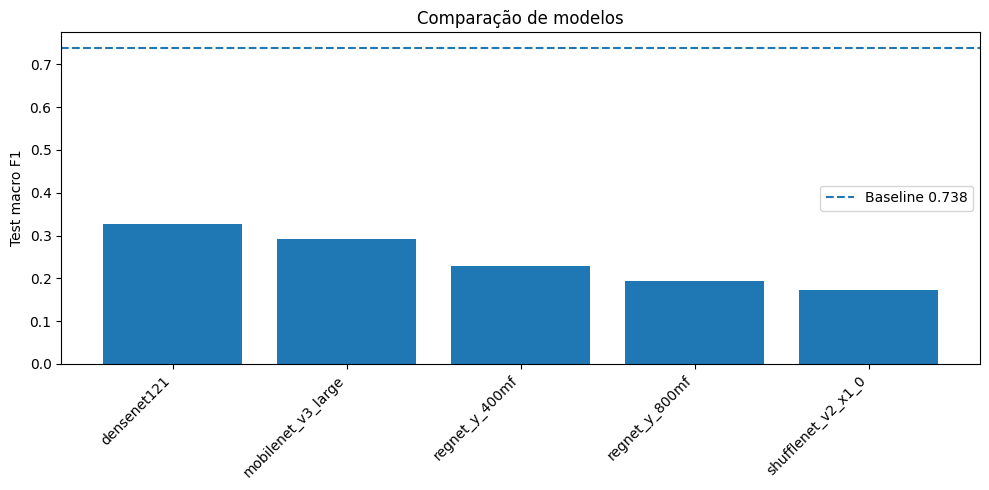

Gráfico guardado em: /mounts/mecd-ap-g5/results/benchmark_models_4class/benchmark_macro_f1.png


In [11]:
# =========================
# 10. Gráfico comparativo
# =========================

if len(summary_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(summary_df["model"], summary_df["test_macro_f1"])
    plt.axhline(BASELINE_MACRO_F1, linestyle="--", label=f"Baseline {BASELINE_MACRO_F1}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Test macro F1")
    plt.title("Comparação de modelos")
    plt.legend()
    plt.tight_layout()

    fig_path = RESULTS_DIR / "benchmark_macro_f1.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Gráfico guardado em:", fig_path)